# EEG Trigger Press · SVM + Regularized LDA — Multi-Trial LOTO CV

Two classical linear/kernel classifiers benchmarked side-by-side:

| Model | Key property |
|---|---|
| **SVM (RBF kernel)** | State-of-the-art for MRCP per Lotte 2007 & Shakeel 2016 (~96% accuracy); Optuna tunes C and gamma |
| **Regularized LDA** | Ledoit-Wolf shrinkage; interpretable single linear projection; near-instant to train |

Both use **Leave-One-Trial-Out (LOTO) CV**, identical preprocessing to the LightGBM notebook,
and the `event_detection_metrics` function for BCI-relevant evaluation.

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys, os, json

import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, classification_report,
)
from sklearn.pipeline import Pipeline
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

sys.path.insert(0, '..')
from src.preprocessing import build_windows, load_trial, make_horizon_labels
from src.postproc import event_detection_metrics

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK  = '#0a0e17'; CARD = '#111827'; EDGE = '#1f2937'
TEAL  = '#00e5cc'; CORAL = '#ff4f5e'; GOLD = '#ffc947'
WHITE = '#f0f4ff'; LIME = '#a8ff3e'

print('All imports OK.')

All imports OK.


## 2 · Config

In [2]:
SUBJECT    = 9
TACHE      = 'spt'
ALL_TRIALS = list(range(10))
DATA_PATH  = f'../data/subject{SUBJECT}/'
FS         = 250
DECIM      = 4
STRIDE     = 1
FS_EFF     = FS // DECIM
LP, HP     = 0.5, 8.0     # MRCP band 0.5–8 Hz
HORIZON    = int(1.0 * FS_EFF)  # 1000 ms Bereitschaftspotential
TARGET     = 'button'

N_TRIALS_OPTUNA  = 20
MIN_SPECIFICITY  = 0.80
SMOOTH_WINDOW_S  = 0.5
SMOOTH_WINDOW    = int(SMOOTH_WINDOW_S * FS_EFF)

T_MAX_S = 1.5
T_MAX   = int(T_MAX_S * FS_EFF)
OPTUNA_FOLDS = ALL_TRIALS[::2]  # 5 folds during Optuna search

# SVM-specific: cap training samples per LOTO fold to keep kernel matrix tractable.
# Using decision_function (no Platt scaling) for ~5x speedup vs probability=True.
SVM_TRAIN_MAX = 8_000   # total balanced training samples per fold (4000 per class)
RANDOM_SEED   = 42

print(f'FS / FS_EFF    : {FS} Hz → {FS_EFF} Hz  (DECIM={DECIM})')
print(f'LP / HP        : {LP} – {HP} Hz')
print(f'HORIZON        : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)')
print(f'T_MAX          : {T_MAX} samples  ({T_MAX/FS_EFF*1000:.0f} ms)')
print(f'SMOOTH_WINDOW  : {SMOOTH_WINDOW} samples  ({SMOOTH_WINDOW/FS_EFF*1000:.0f} ms)')
print(f'SVM_TRAIN_MAX  : {SVM_TRAIN_MAX:,}  ({SVM_TRAIN_MAX//2:,} per class)')


FS / FS_EFF    : 250 Hz → 62 Hz  (DECIM=4)
LP / HP        : 0.5 – 8.0 Hz
HORIZON        : 62 samples  (1000 ms)
T_MAX          : 93 samples  (1500 ms)
SMOOTH_WINDOW  : 31 samples  (500 ms)
SVM_TRAIN_MAX  : 8,000  (4,000 per class)


## 3 · Load & Filter All Trials

In [3]:
print('Loading and filtering all trials …')
raw_data = {}
EEG_COLS = None

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT, TACHE, t, DATA_PATH,
        eeg_cols=EEG_COLS, lp=LP, hp=HP, decimate=DECIM,
        car=True
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    y_momentary_t = df[TARGET].values.astype(np.int8)
    raw_data[t] = (X_t, y_t, y_momentary_t)
    n_press = int(y_t.sum())
    print(
        f'  trial {t:2d}: {len(df):6,} samples  '
        f'horizon-press={n_press:5,} ({n_press/len(df)*100:.1f}%)'
    )

N_CHANNELS = len(EEG_COLS)
print(f'\nChannels ({N_CHANNELS}): {EEG_COLS}')

Loading and filtering all trials …
Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


- Windowed time-domain design (firwin) method


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


  trial  9:  4,298 samples  horizon-press=2,558 (59.5%)

Channels (16): ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


## 4 · Pre-compute Windows at T_MAX

In [4]:
print(f'Pre-computing windows at T_MAX={T_MAX} …')
_X_raw, _y_raw, _y_mom_raw, _tid_raw = [], [], [], []

for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False, stride=STRIDE)
    # also track momentary labels aligned to window endpoints
    y_mom_win = y_mom_t[T_MAX:len(y_mom_t):STRIDE]
    n = min(len(yw), len(y_mom_win))
    _X_raw.append(Xw[:n].reshape(-1, T_MAX, N_CHANNELS))
    _y_raw.append(yw[:n])
    _y_mom_raw.append(y_mom_win[:n])
    _tid_raw.append(np.full(n, _t, dtype=np.int32))

_X_max   = np.concatenate(_X_raw)    # (M, T_MAX, C)
_y_max   = np.concatenate(_y_raw)
_y_mom   = np.concatenate(_y_mom_raw)
_tid_max = np.concatenate(_tid_raw)
del _X_raw, _y_raw, _y_mom_raw, _tid_raw

n_press = int(_y_max.sum())
print(f'  shape={_X_max.shape}  memory={_X_max.nbytes/1e9:.2f} GB')
print(f'  windows={len(_y_max):,}  press={n_press:,} ({n_press/len(_y_max)*100:.1f}%)')


def get_windows_for_T(T: int):
    """Slice pre-computed array to T lags + vectorised per-window z-score."""
    X = _X_max[:, T_MAX - T:, :].copy()   # (M, T, C)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).reshape(len(_y_max), T * N_CHANNELS), _y_max, _tid_max


def subsample_balanced(X, y, n_total, seed):
    """Draw min(n_total/2, n_minority) samples from each class. Returns balanced subset."""
    rng = np.random.default_rng(seed)
    idx0, idx1 = np.where(y == 0)[0], np.where(y == 1)[0]
    n_each = min(n_total // 2, len(idx0), len(idx1))
    sel = np.concatenate([
        rng.choice(idx0, n_each, replace=False),
        rng.choice(idx1, n_each, replace=False),
    ])
    rng.shuffle(sel)
    return X[sel], y[sel]


def smooth_probs(probs, window=SMOOTH_WINDOW):
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def best_threshold(fpr, tpr, thresholds, min_spec=MIN_SPECIFICITY):
    valid = (1 - fpr) >= min_spec
    if valid.any():
        return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])

Pre-computing windows at T_MAX=93 …


  shape=(41414, 93, 16)  memory=0.25 GB
  windows=41,414  press=22,828 (55.1%)


## 5 · SVM — Optuna Search (RBF kernel)

SVM with RBF kernel is the top-performing algorithm in both Lotte (2007) and Shakeel (2016).
Optuna searches `T`, `C` (regularisation), and `gamma` (kernel width).

| Hyperparameter | Range |
|---|---|
| T | 4 – T_MAX (log) |
| C | 0.01 – 1000 (log) |
| gamma | 1e-5 – 1.0 (log) |

In [5]:
def svm_objective(trial):
    T     = trial.suggest_int('T', max(4, FS_EFF // 16), T_MAX, log=True)
    C     = trial.suggest_float('C', 0.01, 1000.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-5, 1.0, log=True)

    X_p, y_p, tid_p = get_windows_for_T(T)

    # probability=False avoids Platt scaling (5x internal CV) — ~5x faster.
    # decision_function gives a valid monotone score for ROC-AUC.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=C, kernel='rbf', gamma=gamma, probability=False,
                    class_weight='balanced', random_state=42)),
    ])

    fold_aucs = []
    for fold, test_trial in enumerate(OPTUNA_FOLDS):
        te_mask = tid_p == test_trial
        X_te, y_te = X_p[te_mask].astype(np.float64), y_p[te_mask]
        X_tr_all, y_tr_all = X_p[~te_mask], y_p[~te_mask]

        X_tr, y_tr = subsample_balanced(
            X_tr_all.astype(np.float64), y_tr_all,
            n_total=SVM_TRAIN_MAX, seed=trial.number + fold
        )

        pipe.fit(X_tr, y_tr)
        scores = pipe.decision_function(X_te)
        auc = roc_auc_score(y_te, scores)
        fold_aucs.append(auc)

        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


svm_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
svm_study.optimize(svm_objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f'\nBest trial : #{svm_study.best_trial.number}')
print(f'Best AUC   : {svm_study.best_value:.4f}')
print('\nBest params:')
for k, v in svm_study.best_params.items():
    print(f'  {k:10s}: {v}')


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial : #13
Best AUC   : 0.6420

Best params:
  T         : 92
  C         : 2.3914723565283245
  gamma     : 0.0007311714629671272


## 6 · SVM — Full LOTO Evaluation

In [6]:
p_svm = svm_study.best_params
T_svm = p_svm['T']

X_pool, y_pool, tid_pool = get_windows_for_T(T_svm)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        C=p_svm['C'], kernel='rbf', gamma=p_svm['gamma'],
        probability=False, class_weight='balanced', random_state=42
    )),
])

svm_aucs, svm_aps = [], []
svm_scores = np.zeros(len(y_pool), dtype=np.float32)

for test_trial in ALL_TRIALS:
    te_mask = tid_pool == test_trial
    X_te, y_te = X_pool[te_mask].astype(np.float64), y_pool[te_mask]
    X_tr_all, y_tr_all = X_pool[~te_mask], y_pool[~te_mask]

    X_tr, y_tr = subsample_balanced(
        X_tr_all.astype(np.float64), y_tr_all,
        n_total=SVM_TRAIN_MAX, seed=RANDOM_SEED + test_trial
    )
    n_tr = len(y_tr)

    svm_pipe.fit(X_tr, y_tr)
    scores = svm_pipe.decision_function(X_te)
    svm_scores[te_mask] = scores.astype(np.float32)

    auc = roc_auc_score(y_te, scores)
    ap  = average_precision_score(y_te, scores)
    svm_aucs.append(auc)
    svm_aps.append(ap)
    print(f'  trial {test_trial:2d} (test)  AUC={auc:.4f}  AP={ap:.4f}  '
          f'n_train={n_tr:,}  n_test={te_mask.sum():,}')

# Smooth scores per trial (decision function values, monotone with probability)
svm_probs = svm_scores  # alias — smoothing works on any monotone score
svm_probs_s = np.zeros_like(svm_probs)
for t in ALL_TRIALS:
    m = tid_pool == t
    svm_probs_s[m] = smooth_probs(svm_probs[m])

fpr_s, tpr_s, thr_s = roc_curve(y_pool, svm_probs_s)
svm_thresh = best_threshold(fpr_s, tpr_s, thr_s)
svm_preds  = (svm_probs_s >= svm_thresh).astype(int)
svm_auc_s  = roc_auc_score(y_pool, svm_probs_s)
svm_ap_s   = average_precision_score(y_pool, svm_probs_s)

print(f'\nSVM LOTO AUC       : {np.mean(svm_aucs):.4f} ± {np.std(svm_aucs):.4f}')
print(f'SVM LOTO AP        : {np.mean(svm_aps):.4f} ± {np.std(svm_aps):.4f}')
print(f'SVM smooth AUC     : {svm_auc_s:.4f}')
print(f'SVM smooth AP      : {svm_ap_s:.4f}')
print(f'SVM threshold      : {svm_thresh:.3f}')
print()
print(classification_report(y_pool, svm_preds, target_names=['Not pressed', 'Pressed']))


  trial  0 (test)  AUC=0.6330  AP=0.3846  n_train=8,000  n_test=4,992


  trial  1 (test)  AUC=0.7301  AP=0.6880  n_train=8,000  n_test=4,054


  trial  2 (test)  AUC=0.6568  AP=0.6982  n_train=8,000  n_test=3,798


  trial  3 (test)  AUC=0.5904  AP=0.5892  n_train=8,000  n_test=4,035


  trial  4 (test)  AUC=0.5999  AP=0.6888  n_train=8,000  n_test=3,853


  trial  5 (test)  AUC=0.5622  AP=0.6380  n_train=8,000  n_test=4,269


  trial  6 (test)  AUC=0.6320  AP=0.7463  n_train=8,000  n_test=4,450


  trial  7 (test)  AUC=0.6475  AP=0.7563  n_train=8,000  n_test=4,101


  trial  8 (test)  AUC=0.6898  AP=0.8178  n_train=8,000  n_test=3,657


  trial  9 (test)  AUC=0.6520  AP=0.7276  n_train=8,000  n_test=4,205

SVM LOTO AUC       : 0.6394 ± 0.0462
SVM LOTO AP        : 0.6735 ± 0.1135
SVM smooth AUC     : 0.6130
SVM smooth AP      : 0.6502
SVM threshold      : 0.331

              precision    recall  f1-score   support

 Not pressed       0.50      0.80      0.62     18586
     Pressed       0.68      0.35      0.46     22828

    accuracy                           0.55     41414
   macro avg       0.59      0.58      0.54     41414
weighted avg       0.60      0.55      0.53     41414



## 7 · Regularized LDA — LOTO Evaluation

Ledoit-Wolf shrinkage (`shrinkage='auto'`) regularises the covariance estimate — critical
when `n_features > n_samples`, which happens at large T.  No Optuna needed: the shrinkage
parameter is estimated analytically.

We sweep T from `FS_EFF//8` (125 ms) to `T_MAX` in steps and pick the T with highest mean LOTO AUC.

In [7]:
T_candidates = list(range(max(4, FS_EFF // 8), T_MAX + 1, max(1, T_MAX // 20)))
print(f'Sweeping T in {len(T_candidates)} values: {T_candidates[:5]} … {T_candidates[-3:]}')

lda_results = []
for T_cand in T_candidates:
    X_p, y_p, tid_p = get_windows_for_T(T_cand)
    X_p64 = X_p.astype(np.float64)

    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    fold_aucs = []
    for test_trial in OPTUNA_FOLDS:
        te = tid_p == test_trial
        lda.fit(X_p64[~te], y_p[~te])
        probs = lda.predict_proba(X_p64[te])[:, 1]
        fold_aucs.append(roc_auc_score(y_p[te], probs))
    lda_results.append({'T': T_cand, 'auc': float(np.mean(fold_aucs))})

best_lda = max(lda_results, key=lambda x: x['auc'])
T_lda = best_lda['T']
print(f'\nBest LDA T : {T_lda} samples  ({T_lda/FS_EFF*1000:.0f} ms)  AUC={best_lda["auc"]:.4f}')

Sweeping T in 22 values: [7, 11, 15, 19, 23] … [83, 87, 91]



Best LDA T : 55 samples  (887 ms)  AUC=0.6454


In [8]:
X_lda, y_lda, tid_lda = get_windows_for_T(T_lda)
X_lda64 = X_lda.astype(np.float64)

lda_model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_aucs, lda_aps = [], []
lda_probs = np.zeros(len(y_lda), dtype=np.float32)

for test_trial in ALL_TRIALS:
    te_mask = tid_lda == test_trial
    X_te, y_te = X_lda64[te_mask], y_lda[te_mask]
    X_tr, y_tr = X_lda64[~te_mask], y_lda[~te_mask]

    lda_model.fit(X_tr, y_tr)
    probs = lda_model.predict_proba(X_te)[:, 1]
    lda_probs[te_mask] = probs

    auc = roc_auc_score(y_te, probs)
    ap  = average_precision_score(y_te, probs)
    lda_aucs.append(auc)
    lda_aps.append(ap)
    print(f'  trial {test_trial:2d} (test)  AUC={auc:.4f}  AP={ap:.4f}  n={te_mask.sum():,}')

# Smooth + threshold
lda_probs_s = np.zeros_like(lda_probs)
for t in ALL_TRIALS:
    m = tid_lda == t
    lda_probs_s[m] = smooth_probs(lda_probs[m])

fpr_l, tpr_l, thr_l = roc_curve(y_lda, lda_probs_s)
lda_thresh = best_threshold(fpr_l, tpr_l, thr_l)
lda_preds  = (lda_probs_s >= lda_thresh).astype(int)
lda_auc_s  = roc_auc_score(y_lda, lda_probs_s)
lda_ap_s   = average_precision_score(y_lda, lda_probs_s)

print(f'\nLDA LOTO AUC       : {np.mean(lda_aucs):.4f} ± {np.std(lda_aucs):.4f}')
print(f'LDA LOTO AP        : {np.mean(lda_aps):.4f} ± {np.std(lda_aps):.4f}')
print(f'LDA smooth AUC     : {lda_auc_s:.4f}')
print(f'LDA smooth AP      : {lda_ap_s:.4f}')
print(f'LDA threshold      : {lda_thresh:.3f}')
print()
print(classification_report(y_lda, lda_preds, target_names=['Not pressed', 'Pressed']))

  trial  0 (test)  AUC=0.6473  AP=0.3862  n=4,992


  trial  1 (test)  AUC=0.6626  AP=0.5712  n=4,054


  trial  2 (test)  AUC=0.6304  AP=0.6782  n=3,798


  trial  3 (test)  AUC=0.5668  AP=0.5311  n=4,035


  trial  4 (test)  AUC=0.5702  AP=0.6921  n=3,853


  trial  5 (test)  AUC=0.6098  AP=0.6691  n=4,269


  trial  6 (test)  AUC=0.6775  AP=0.7390  n=4,450


  trial  7 (test)  AUC=0.6727  AP=0.7479  n=4,101


  trial  8 (test)  AUC=0.7014  AP=0.8198  n=3,657


  trial  9 (test)  AUC=0.7063  AP=0.7325  n=4,205

LDA LOTO AUC       : 0.6445 ± 0.0472
LDA LOTO AP        : 0.6567 ± 0.1207
LDA smooth AUC     : 0.6000
LDA smooth AP      : 0.6116
LDA threshold      : 0.652

              precision    recall  f1-score   support

 Not pressed       0.47      0.80      0.60     18586
     Pressed       0.63      0.28      0.39     22828

    accuracy                           0.51     41414
   macro avg       0.55      0.54      0.49     41414
weighted avg       0.56      0.51      0.48     41414



## 8 · Event-Level Detection Metrics

In [9]:
# Use original (momentary) labels aligned to the SVM window endpoints
# _y_mom was built in the pre-compute cell; re-align to T_svm windows
_, _, tid_svm = get_windows_for_T(T_svm)

# Recompute momentary labels aligned for T_svm
y_mom_svm = []
for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    _, yw = build_windows(X_t, y_t, T_svm, per_window_norm=False, stride=STRIDE)
    y_mom_win = y_mom_t[T_svm:len(y_mom_t):STRIDE][:len(yw)]
    y_mom_svm.append(y_mom_win)
y_mom_svm = np.concatenate(y_mom_svm).astype(np.int8)

print('=== SVM Event-Level Metrics ===')
svm_evt = event_detection_metrics(
    svm_probs_s, y_mom_svm, threshold=svm_thresh,
    horizon=HORIZON, fs_eff=FS_EFF
)
for k, v in svm_evt.items():
    print(f'  {k:22s}: {v:.3f}' if isinstance(v, float) else f'  {k:22s}: {v}')

# Recompute for LDA
y_mom_lda = []
for _t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[_t]
    _, yw = build_windows(X_t, y_t, T_lda, per_window_norm=False, stride=STRIDE)
    y_mom_win = y_mom_t[T_lda:len(y_mom_t):STRIDE][:len(yw)]
    y_mom_lda.append(y_mom_win)
y_mom_lda = np.concatenate(y_mom_lda).astype(np.int8)

print('\n=== LDA Event-Level Metrics ===')
lda_evt = event_detection_metrics(
    lda_probs_s, y_mom_lda, threshold=lda_thresh,
    horizon=HORIZON, fs_eff=FS_EFF
)
for k, v in lda_evt.items():
    print(f'  {k:22s}: {v:.3f}' if isinstance(v, float) else f'  {k:22s}: {v}')

=== SVM Event-Level Metrics ===
  event_sensitivity     : 0.745
  fa_per_minute         : 34.390
  mean_latency_ms       : 676.926
  n_events              : 263
  n_detected            : 196
  n_false_alarms        : 232

=== LDA Event-Level Metrics ===
  event_sensitivity     : 0.608
  fa_per_minute         : 32.854
  mean_latency_ms       : 751.109
  n_events              : 263
  n_detected            : 160
  n_false_alarms        : 223


## 9 · Results Summary & Comparison

In [10]:
print('=' * 65)
print('  EEG Trigger Press — SVM vs LDA  (LOTO CV)')
print('=' * 65)
print(f'  Band-pass    : {LP} – {HP} Hz')
print(f'  HORIZON      : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)')
print()
print(f'  {"":22s}  {"SVM (RBF)":>10s}  {"RLDA":>10s}')
print(f'  {"-"*44}')
print(f'  {"T (ms)":22s}  {T_svm/FS_EFF*1000:>10.0f}  {T_lda/FS_EFF*1000:>10.0f}')
print(f'  {"LOTO AUC":22s}  {np.mean(svm_aucs):>10.4f}  {np.mean(lda_aucs):>10.4f}')
print(f'  {"LOTO AP":22s}  {np.mean(svm_aps):>10.4f}  {np.mean(lda_aps):>10.4f}')
print(f'  {"Smooth AUC":22s}  {svm_auc_s:>10.4f}  {lda_auc_s:>10.4f}')
print(f'  {"Event sensitivity":22s}  {svm_evt["event_sensitivity"]:>10.3f}  {lda_evt["event_sensitivity"]:>10.3f}')
print(f'  {"FA / min":22s}  {svm_evt["fa_per_minute"]:>10.1f}  {lda_evt["fa_per_minute"]:>10.1f}')
print(f'  {"Mean latency (ms)":22s}  {svm_evt["mean_latency_ms"]:>10.1f}  {lda_evt["mean_latency_ms"]:>10.1f}')
print('=' * 65)

  EEG Trigger Press — SVM vs LDA  (LOTO CV)
  Band-pass    : 0.5 – 8.0 Hz
  HORIZON      : 62 samples  (1000 ms)

                           SVM (RBF)        RLDA
  --------------------------------------------
  T (ms)                        1484         887
  LOTO AUC                    0.6394      0.6445
  LOTO AP                     0.6735      0.6567
  Smooth AUC                  0.6130      0.6000
  Event sensitivity            0.745       0.608
  FA / min                      34.4        32.9
  Mean latency (ms)            676.9       751.1


## 10 · ROC & PR Curves

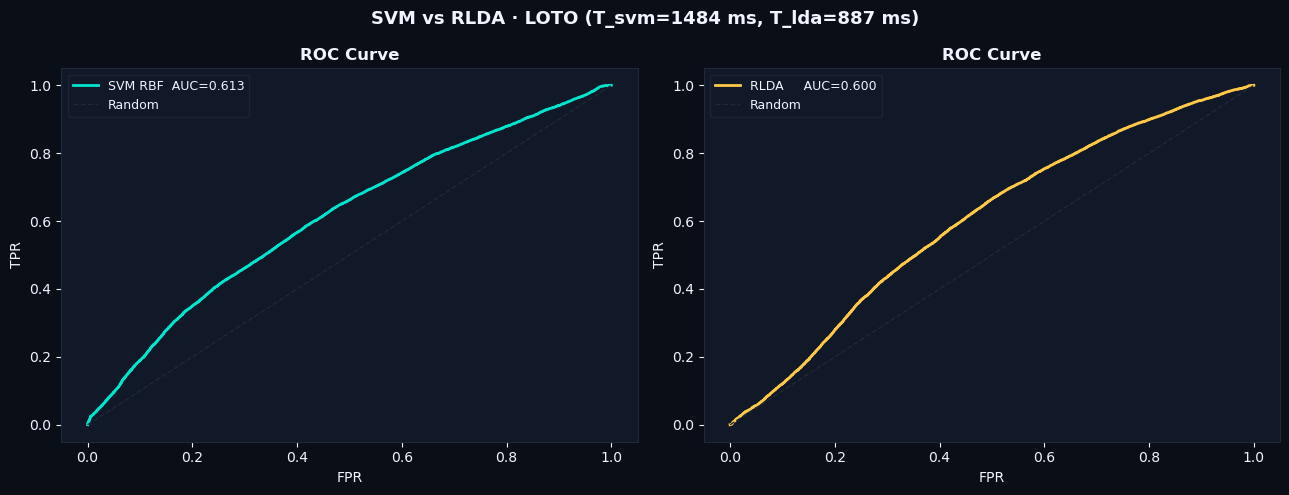

In [11]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK)

for ax, (probs_s, y_p, auc_s, label, color) in zip(axes, [
    (svm_probs_s, y_pool, svm_auc_s, f'SVM RBF  AUC={svm_auc_s:.3f}', TEAL),
    (lda_probs_s, y_lda,  lda_auc_s, f'RLDA     AUC={lda_auc_s:.3f}', GOLD),
]):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values(): sp.set_color(EDGE)
    fpr_, tpr_, _ = roc_curve(y_p, probs_s)
    ax.plot(fpr_, tpr_, color=color, lw=2, label=label)
    ax.plot([0, 1], [0, 1], color=EDGE, lw=1, ls='--', label='Random')
    ax.set_xlabel('FPR', color=WHITE); ax.set_ylabel('TPR', color=WHITE)
    ax.set_title('ROC Curve', color=WHITE, fontweight='bold')
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=9)

plt.suptitle(
    f'SVM vs RLDA · LOTO (T_svm={T_svm/FS_EFF*1000:.0f} ms, T_lda={T_lda/FS_EFF*1000:.0f} ms)',
    color=WHITE, fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 11 · Probability Timeline (one trial)

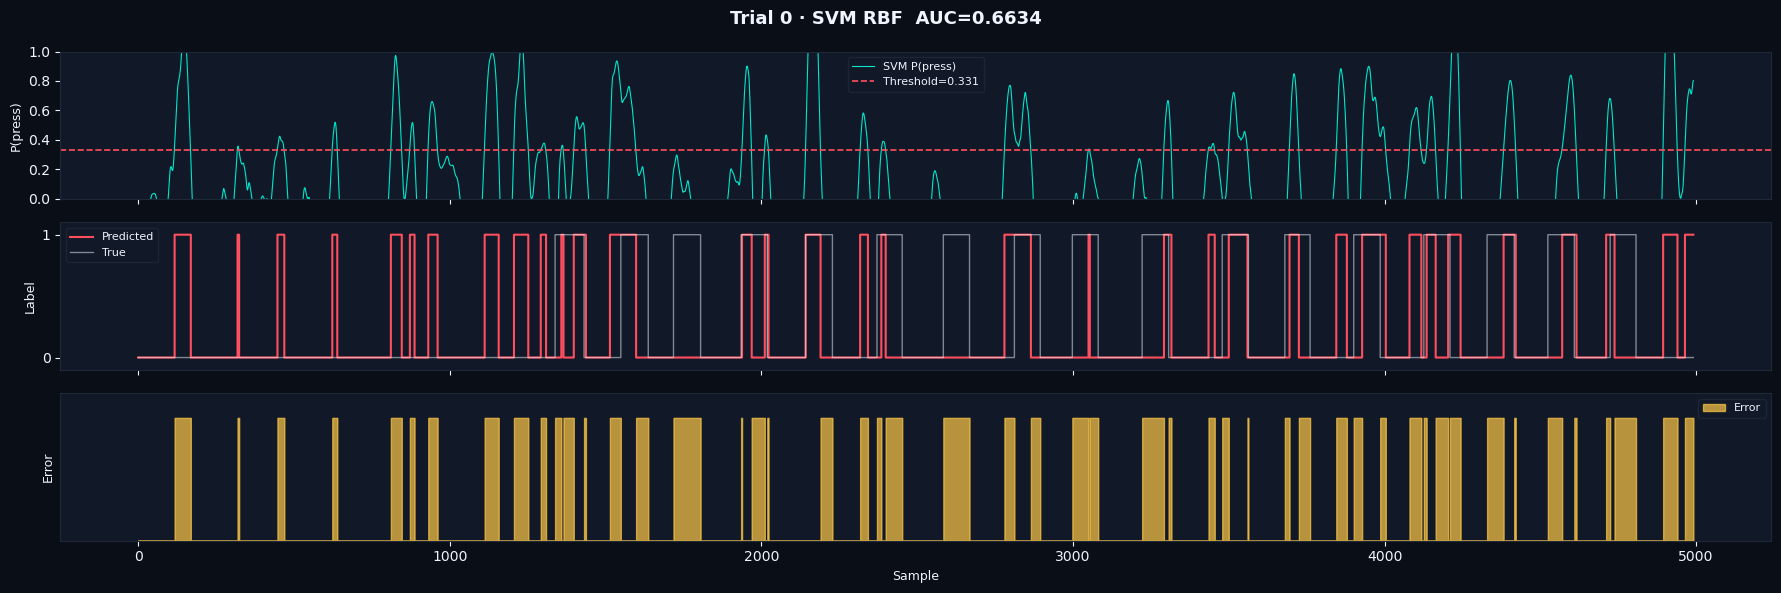

In [12]:
%matplotlib inline
SHOW_TRIAL = 0

mask_t = tid_pool == SHOW_TRIAL
probs_t = svm_probs_s[mask_t]
y_t     = y_pool[mask_t]
preds_t = (probs_t >= svm_thresh).astype(int)

fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
t_ax = np.arange(len(probs_t))

ax = axes[0]
ax.set_facecolor(CARD)
ax.plot(t_ax, probs_t, color=TEAL, lw=0.8, label='SVM P(press)')
ax.axhline(svm_thresh, color=CORAL, lw=1.2, ls='--', label=f'Threshold={svm_thresh:.3f}')
ax.set_ylim(0, 1); ax.set_ylabel('P(press)', color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(t_ax, preds_t, drawstyle='steps-post', color=CORAL, lw=1.5, label='Predicted')
ax.plot(t_ax, y_t, drawstyle='steps-post', color=WHITE, lw=1.0, alpha=0.5, label='True')
ax.set_ylim(-0.1, 1.1); ax.set_yticks([0, 1])
ax.set_ylabel('Label', color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

ax = axes[2]
ax.set_facecolor(CARD)
errors = (preds_t != y_t).astype(float)
ax.fill_between(t_ax, errors, color=GOLD, alpha=0.7, step='post', label='Error')
ax.set_ylim(0, 1.2); ax.set_yticks([])
ax.set_ylabel('Error', color=WHITE, fontsize=9)
ax.set_xlabel('Sample', color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values(): sp.set_color(EDGE)

fig.suptitle(
    f'Trial {SHOW_TRIAL} · SVM RBF  AUC={roc_auc_score(y_t, probs_t):.4f}',
    color=WHITE, fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()